# A Framework for Leveraging LLMs for Scene Analysis and Cognitive Processing

In [1]:
import os
HOME = os.getcwd()

os.chdir(HOME)
print(HOME)

d:\home\Documents\Github\human_patterns_exploration


In [2]:
HOME = os.getcwd()
os.chdir(HOME)

DATA_DIR = os.path.join(".", "data", "experiments")
IMAGE_DIR = os.path.join(".", "data", "images")
RESULTS_DIR = os.path.join(".", "outputs")


In [3]:
from src.models.LLM import LLM, OpenAI, Ollama
from src.models.Framework import SceneUnderstandingFramework
from src.utils.llm_utils import create_llm_instance
from src.core.ImageData import ImageData
from src.models.KG import KnowledgeGraph
import os
import pickle

In [4]:
IMG_ID = 1
IMG_TYPE = "exp"
llm_provider = "openai"

IMG_PATH = os.path.join(IMAGE_DIR, f"{IMG_ID}{IMG_TYPE}.jpg")
image_data = ImageData(path=IMG_PATH, img_type=IMG_TYPE)

# load img scene description
scene_descr_path = os.path.join(RESULTS_DIR, "SceneDescriptions", f"{llm_provider}_results", f"IMG_{IMG_ID}_{IMG_TYPE}_descr.txt")
image_data.load_scene_description(scene_descr_path)

print(image_data.description)

1. **Scene Overview**:  
   The image depicts a modern, multifunctional living space that combines elements of a laundry area and a cozy sitting area. The room features a light color palette with a mix of functional furniture and decorative items, creating a warm and inviting atmosphere.

2. **Identified Objects**:  
   - **Washing Machine**: Located on the left side of the image, it has a front-loading door and is white in color.
   - **Dryer**: Positioned next to the washing machine, also white, with a similar front-loading design.
   - **Storage Cabinets**: Above the washing machine and dryer, there are white cabinets with multiple doors, providing storage space.
   - **Desk**: A long, white desk is situated in the center of the image, extending from the washing machine to the right side.
   - **Chair**: A black chair is placed in front of the desk.
   - **Desk Items**: Various items on the desk include colored cones, stationery, a sewing machine, and a few decorative objects.
   - 

In [7]:
# load masks
masks_path_dir = os.path.join(RESULTS_DIR, "Masks", "BestMask")
image_data.load_img_masks( masks_path_dir )
print(f"Loaded a total of {len(image_data.masks)} Masks for IMG {image_data.ID}_{image_data.img_type}")

Loaded a total of 357 Masks for IMG 1_exp


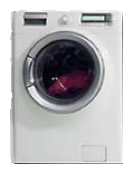

['washing', 'washing', 'washing', 'washing', 'washing', 'washing', 'washing', 'washing', 'washing', 'washing']
washing
1.0


In [8]:
# checking if everything is okay
image_data.masks[5].plot()
print(image_data.masks[5].labels)
print(image_data.masks[5].most_freq_label)
print(image_data.masks[5].most_freq_prob)

In [9]:
# call the KG builder
llm = create_llm_instance("openai", "gpt-4o-mini", temperature = 0.1)
KG = KnowledgeGraph(llm, image_data)

In [ ]:
KG.load_triples( os.path.join(RESULTS_DIR, "KnowledgeGraph", "triples_final", "IMG_1_exp_triples.txt") );

In [ ]:
KG.plot_relationship_matrix()

In [ ]:
KG.build_graph()